#### MNIST FCN

Reparameterizes the dummy image using a sigmoid: Instead of directly optimizing over a variable representing an image (which may take values outside 0,1), we optimize an unconstrained variable and pass it through a sigmoid so that the dummy image is always in the valid range.

Increases the number of iterations: More updates sometimes help push the dummy image closer to the target.

Adds a slight regularization term: A total variation (TV) regularization term is added to encourage smoothness and promote natural-looking reconstructions.

Explanation:
- Reparameterization using Sigmoid: By optimizing dummy_param and then applying tf.sigmoid(dummy_param), we ensure that our dummy image always has pixel values between 0 and 1. This aligns our optimization with the natural image space.
- Extended Optimization Iterations: Increased iterations (set here to 1000) provide the optimizer more time to reduce the gradient difference. Depending on your setup, you might even experiment with more iterations.
- Total Variation Regularization: The added regularization term tf.image.total_variation(dummy_data) penalizes abrupt changes in the image, thereby promoting smoothness. The regularization weight (0.001) is modest, but you may tweak it based on the reconstruction quality and how much “smoothness” you intend to enforce.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
import numpy as np
import matplotlib.pyplot as plt

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

# -----------------------------------
# 1. Define a Simple Neural Network
# -----------------------------------
def create_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10)  # Logits for 10 classes
    ])
    return model

model = create_model()

# -----------------------------------
# 2. Load MNIST and Select a Target Sample
# -----------------------------------
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)  # Shape: (batch, 28, 28, 1)

# Choose one target sample
target_data = tf.convert_to_tensor(train_images[0:1])
target_label = tf.convert_to_tensor(train_labels[0:1])

# -----------------------------------
# 3. Compute the Target Gradients
# -----------------------------------
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

with tf.GradientTape() as tape:
    logits = model(target_data)
    target_loss = loss_fn(target_label, logits)
target_grads = tape.gradient(target_loss, model.trainable_variables)

# -----------------------------------
# 4. Simulate the Gradient Leakage Attack with Improvements
# -----------------------------------
# Instead of optimizing dummy data directly, we optimize an unconstrained variable that we
# transform through a sigmoid function to ensure the dummy image is in [0,1].
dummy_param = tf.Variable(tf.random.normal(shape=target_data.shape), trainable=True)

def get_dummy_image():
    # Enforces valid image pixel range
    return tf.sigmoid(dummy_param)

# Use Adam optimizer; you might adjust the learning rate and further fine-tune as needed.
optimizer = optimizers.Adam(learning_rate=0.1)

num_iterations = 1000  # Increased iterations for potentially better convergence

print("Starting the reconstruction attack...")
for i in range(num_iterations):
    with tf.GradientTape() as outer_tape:
        dummy_data = get_dummy_image()
        # Inner tape to compute gradients w.r.t. model parameters for dummy data
        with tf.GradientTape() as inner_tape:
            dummy_logits = model(dummy_data)
            dummy_loss = loss_fn(target_label, dummy_logits)
        dummy_grads = inner_tape.gradient(dummy_loss, model.trainable_variables)
        
        # Compute the L2 difference between dummy gradients and target gradients
        grad_diff = 0.0
        for dg, tg in zip(dummy_grads, target_grads):
            grad_diff += tf.reduce_sum(tf.square(dg - tg))
        
        # Add a regularization term: total variation loss to encourage smoothness.
        reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
        # The regularization weight (0.001) can be tweaked to balance reconstruction vs. smoothness.
        total_loss = grad_diff + 0.001 * reg_loss

    # Compute the gradient of the loss with respect to the dummy parameters (not the image directly).
    grad_dummy = outer_tape.gradient(total_loss, dummy_param)
    optimizer.apply_gradients([(grad_dummy, dummy_param)])
    
    if i % 100 == 0:
        print(f"Iteration {i}, Total loss: {total_loss.numpy():.4f}")

# -----------------------------------
# 5. Visualize the Results
# -----------------------------------
dummy_image = get_dummy_image().numpy().squeeze()   # Reconstructed image from gradients
target_image = target_data.numpy().squeeze()          # Original target image

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Target Image")
plt.imshow(target_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image from Gradients")
plt.imshow(dummy_image, cmap='gray')
plt.axis('off')

plt.show()


ModuleNotFoundError: No module named 'tensorflow'

##### Re-run for three samples.

Starting gradient-based attacks on 3 target images...

Attacking target image index: 0
Iteration 0, Total loss: 156.2361
Iteration 100, Total loss: 51.8470
Iteration 200, Total loss: 6.1748
Iteration 300, Total loss: 3.1190
Iteration 400, Total loss: 2.9151
Iteration 500, Total loss: 3.8119
Iteration 600, Total loss: 2.7772
Iteration 700, Total loss: 2.7475
Iteration 800, Total loss: 3.7151
Iteration 900, Total loss: 2.7136

Attacking target image index: 1
Iteration 0, Total loss: 241.9649
Iteration 100, Total loss: 39.2992
Iteration 200, Total loss: 12.4188
Iteration 300, Total loss: 14.4431
Iteration 400, Total loss: 14.6105
Iteration 500, Total loss: 14.9938
Iteration 600, Total loss: 12.9447
Iteration 700, Total loss: 13.3763
Iteration 800, Total loss: 13.3564
Iteration 900, Total loss: 14.4846

Attacking target image index: 2
Iteration 0, Total loss: 230.1955
Iteration 100, Total loss: 57.8788
Iteration 200, Total loss: 51.3802
Iteration 300, Total loss: 43.8084
Iteration 400, Tot

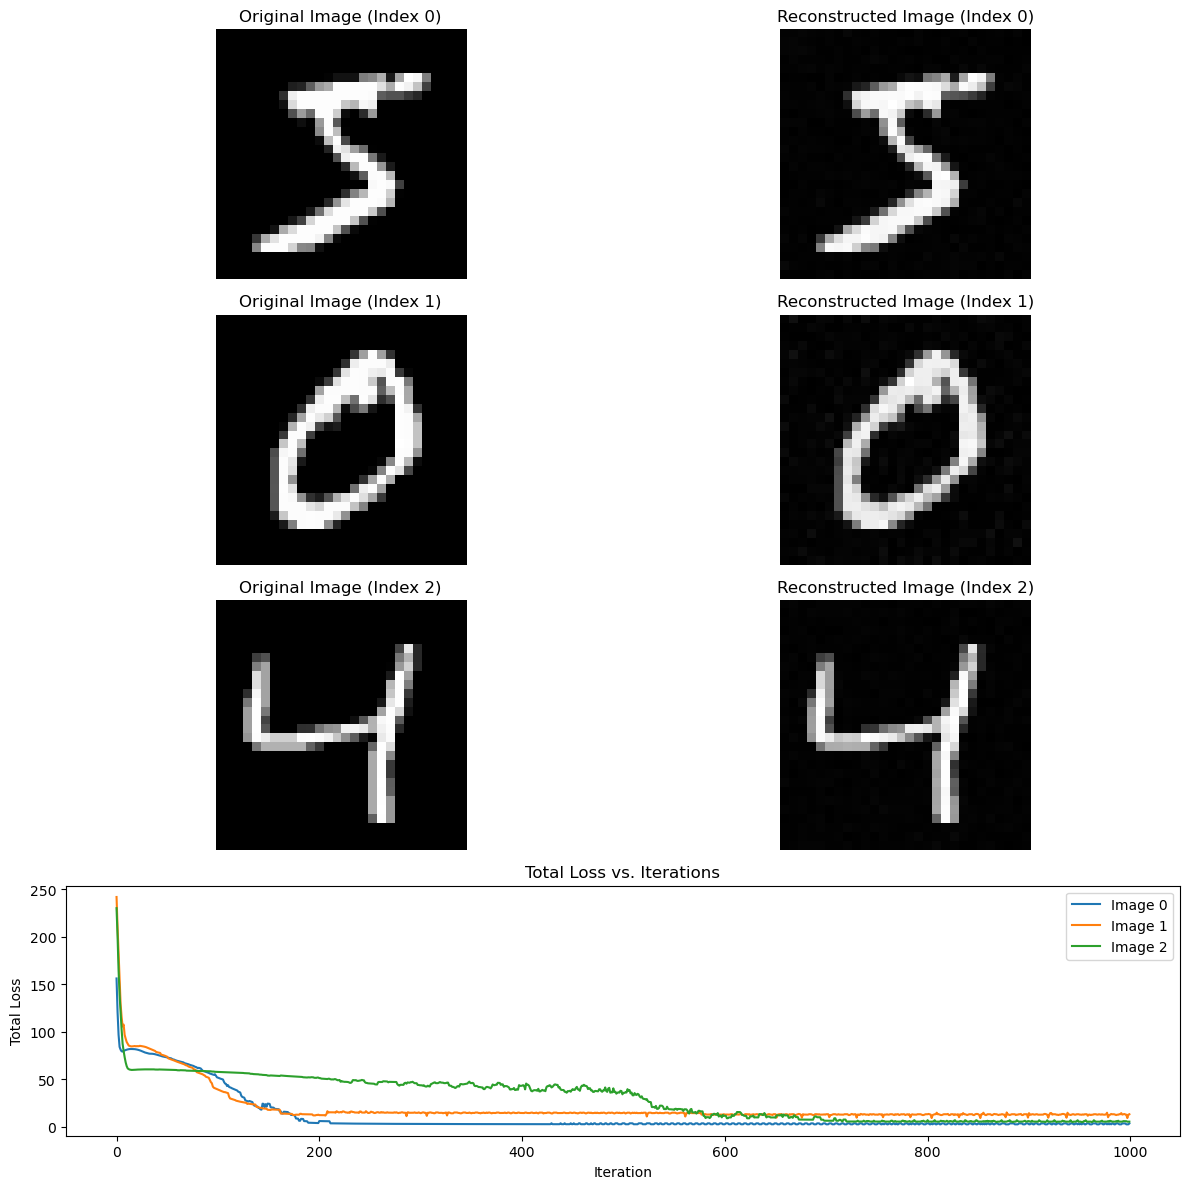

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
from tensorflow.keras.optimizers import legacy as legacy_optimizers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

# -----------------------------------
# 1. Define a Simple Neural Network (FCNN)
# -----------------------------------
def create_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),  # Flatten the input image
        layers.Dense(128, activation='relu'),     # Hidden layer with 128 neurons
        layers.Dense(10)                          # Output logits for 10 classes
    ])
    return model

model = create_model()

# -----------------------------------
# 2. Load MNIST dataset
# -----------------------------------
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)  # Shape: (batch, 28, 28, 1)

# -----------------------------------
# Hyperparameters for the attack and training
# -----------------------------------
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
num_iterations = 1000
reg_weight = 0.001  # Regularization weight for total variation loss

# Lists to store results for each target image
original_images = []
reconstructed_images = []
loss_curves = []

# Define target indices (you can choose any three images from the training set)
target_indices = [0, 1, 2]

print("Starting gradient-based attacks on 3 target images...")

for idx in target_indices:
    print(f"\nAttacking target image index: {idx}")
    
    # Get target image and corresponding label (batch size of 1)
    target_data = tf.convert_to_tensor(train_images[idx:idx+1])
    target_label = tf.convert_to_tensor([train_labels[idx]])
    
    # -----------------------------------
    # 3. Compute the Target Gradients
    # -----------------------------------
    with tf.GradientTape() as tape:
        logits = model(target_data)
        target_loss = loss_fn(target_label, logits)
    target_grads = tape.gradient(target_loss, model.trainable_variables)
    
    # -----------------------------------
    # 4. Simulate the Gradient Leakage Attack
    # -----------------------------------
    # Initialize a dummy parameter for this target image
    dummy_param = tf.Variable(tf.random.normal(shape=target_data.shape), trainable=True)
    # Using the legacy optimizer to ensure the new dummy parameter is recognized
    optimizer = legacy_optimizers.Adam(learning_rate=0.1)
    
    # Define a function to obtain the dummy image (enforcing valid [0,1] range)
    def get_dummy_image():
        return tf.sigmoid(dummy_param)
    
    # Record the loss at every iteration
    loss_history = []
    
    for i in range(num_iterations):
        with tf.GradientTape() as outer_tape:
            dummy_data = get_dummy_image()
            # Inner tape to compute gradients w.r.t. model parameters for dummy data
            with tf.GradientTape() as inner_tape:
                dummy_logits = model(dummy_data)
                dummy_loss = loss_fn(target_label, dummy_logits)
            dummy_grads = inner_tape.gradient(dummy_loss, model.trainable_variables)
            
            # Compute the L2 difference between dummy gradients and target gradients
            grad_diff = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff += tf.reduce_sum(tf.square(dg - tg))
            
            # Add total variation loss for smoothness regularization
            reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
            total_loss = grad_diff + reg_weight * reg_loss
        
        # Compute gradient of total loss with respect to dummy_param and update
        grad_dummy = outer_tape.gradient(total_loss, dummy_param)
        optimizer.apply_gradients([(grad_dummy, dummy_param)])
        
        loss_history.append(total_loss.numpy())
        if i % 100 == 0:
            print(f"Iteration {i}, Total loss: {total_loss.numpy():.4f}")
    
    # Store the results for this target image
    reconstructed_images.append(get_dummy_image().numpy().squeeze())
    original_images.append(target_data.numpy().squeeze())
    loss_curves.append(loss_history)

# -----------------------------------
# 5. Visualize the Results and Save as PDF
# -----------------------------------
# Create a grid with 4 rows and 2 columns: 
# - The first 3 rows display original and reconstructed image pairs for each target.
# - The 4th row spans both columns to show the loss curves.
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(nrows=4, ncols=2, height_ratios=[1,1,1,1])

for i in range(len(target_indices)):
    ax_orig = fig.add_subplot(gs[i, 0])
    ax_orig.imshow(original_images[i], cmap='gray')
    ax_orig.set_title(f"Original Image (Index {target_indices[i]})")
    ax_orig.axis('off')
    
    ax_recon = fig.add_subplot(gs[i, 1])
    ax_recon.imshow(reconstructed_images[i], cmap='gray')
    ax_recon.set_title(f"Reconstructed Image (Index {target_indices[i]})")
    ax_recon.axis('off')

ax_loss = fig.add_subplot(gs[3, :])  # This subplot spans both columns
for i in range(len(target_indices)):
    ax_loss.plot(loss_curves[i], label=f"Image {target_indices[i]}")
ax_loss.set_title("Total Loss vs. Iterations")
ax_loss.set_xlabel("Iteration")
ax_loss.set_ylabel("Total Loss")
ax_loss.legend()

plt.tight_layout()
plt.savefig("attack_results.pdf")  # Save the entire plot in one PDF file
plt.show()


##### Plotting 

C:\Users\rrk307\AppData\Local\Temp\ipykernel_3940\2610230771.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


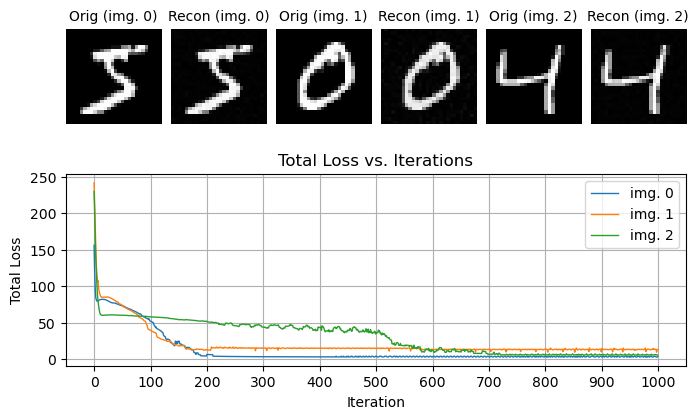

In [58]:
# -----------------------------------
# 5. Visualize the Results and Save as PDF
# -----------------------------------
# Arrange all the image pairs in one row (original and reconstructed images for each target 
# occupy two subplots each, resulting in 6 subplots in the top row) and the loss curves in the 
# bottom row spanning all 6 columns.
fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(nrows=2, ncols=6, height_ratios=[1, 1], hspace=0.01, wspace=0.1)

# Top row: display original and reconstructed images for each target (6 subplots)
for i in range(len(target_indices)):
    ax_orig = fig.add_subplot(gs[0, 2*i])
    ax_orig.imshow(np.squeeze(original_images[i]), cmap='gray')
    ax_orig.set_title(f"Orig (img. {target_indices[i]})", fontsize=10)
    ax_orig.axis('off')
    
    ax_recon = fig.add_subplot(gs[0, 2*i+1])
    ax_recon.imshow(np.squeeze(reconstructed_images[i]), cmap='gray')
    ax_recon.set_title(f"Recon (img. {target_indices[i]})", fontsize=10)
    ax_recon.axis('off')

# Bottom row: loss curve spanning all 6 columns, matching the image row's size
ax_loss = fig.add_subplot(gs[1, :])
for i in range(len(target_indices)):
    ax_loss.plot(loss_curves[i], label=f"img. {target_indices[i]}", linewidth=1)
ax_loss.set_title("Total Loss vs. Iterations", fontsize=12)
ax_loss.set_xlabel("Iteration", fontsize=10)
ax_loss.set_ylabel("Total Loss", fontsize=10)
ax_loss.legend(fontsize=10, loc='upper right')
ax_loss.grid()
ax_loss.set_xticks([0,100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

plt.tight_layout()
plt.savefig("attack_results_mnist.pdf", format="pdf")
plt.show()


#### GCNN Circuit

Training the GCNN for node classification to predict one of the class (gate-type)  ['and', 'or', 'nand', 'nor', 'xor', 'xnor', 'buf', 'not'].

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    
    # Find nodes with fan-out > 0 (likely driving this gate)
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    
    # Assign 'fan_in' number of edges
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src → node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Remove invalid edges (if any)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops to avoid zero in-degree

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

C:\Users\rrk307\Anaconda3\lib\site-packages\dgl\backend\pytorch\tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


Epoch 0/50, Loss: 2.5170
Epoch 10/50, Loss: 1.1856
Epoch 20/50, Loss: 0.5843
Epoch 30/50, Loss: 0.3756
Epoch 40/50, Loss: 0.3059

✅ Test Accuracy: 92.21%

✅ Train Accuracy: 92.20%


In this demonstration, we assume that an attacker has access to the gradients computed from a target node during training. The attack works by treating the target node’s features as an unknown (dummy) variable and then optimizing that dummy variable so that the gradient computed with the dummy features closely matches the target gradients. In this example, we pick one target node (here, the first node from the train mask) and reconstruct its feature vector.

- Computing Target Gradients (Step 8A): We pick one target node (from the training set) and compute the loss (and its gradients with respect to the model parameters) for that node’s forward pass. These gradients represent the “leakage” available to the attacker.

- Dummy Feature Optimization (Step 8B): We initialize a dummy feature vector for the target node (with the same shape as the original features) and repeatedly update it. At each iteration, we form a dummy feature matrix by replacing the target node’s features with the dummy variable. We then compute the loss and gradients for the target node using this dummy matrix, measure the L2 difference between the dummy gradients and our precomputed target gradients, and update the dummy feature accordingly. A slight L2 regularization is added to encourage stability.

- Evaluation and Visualization (Step 8C): Finally, the code prints and plots a comparison between the original target node features and the reconstructed ones.


🔍 Attacking target node index: 51861

Starting GCNN gradient leakage attack on target node...
Iteration 0, Total loss: 15.4525
Iteration 50, Total loss: 0.4004
Iteration 100, Total loss: 0.2239
Iteration 150, Total loss: 0.1521
Iteration 200, Total loss: 0.0642
Iteration 250, Total loss: 0.0362
Iteration 300, Total loss: 0.0056
Iteration 350, Total loss: 0.0013
Iteration 400, Total loss: 0.0013
Iteration 450, Total loss: 0.0013

Original target node feature:
tensor([[ 0.5852,  0.1012,  0.6712, -0.2018, -0.1490,  0.2546, -0.0448,  0.2069,
          0.7434,  0.1079, -0.2078, -0.3259, -0.1754]])

Reconstructed dummy target node feature:
tensor([[ 0.5842,  0.1000,  0.6674, -0.2010, -0.1486,  0.2539, -0.0448,  0.2059,
          0.7388,  0.1074, -0.2069, -0.3243, -0.1745]])


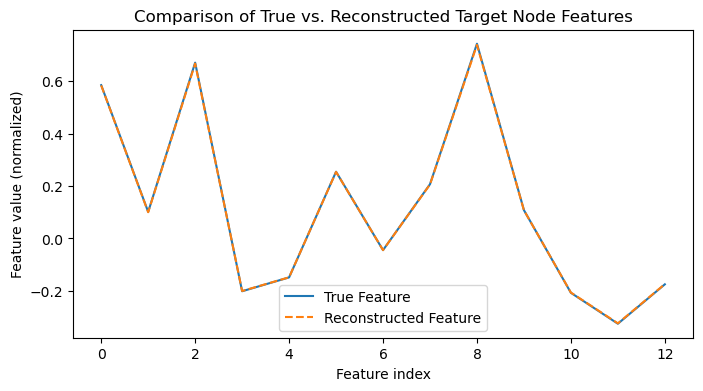

In [4]:
# -------------------------
# Step 8: Gradient Leakage Attack on a Target Node
# -------------------------
# We now demonstrate a gradient inversion attack. For this example, we select one target node
# from the training set (here, the first node in train_mask). Note that in a real scenario, an
# attacker might have access to the gradients computed by the server for that node.

# Pick a target node index (for demonstration, we choose the first node in train_mask)
target_idx = int(train_mask[0])
print(f"\n🔍 Attacking target node index: {target_idx}")

# Ensure the model is in evaluation mode
model.eval()

# Get the original full feature matrix (we will keep other nodes fixed)
features_orig = graph.ndata['features'].clone().detach()  # shape: (num_nodes, in_feats)

# Prepare the target label tensor for our target node
target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()

# -------------------------
# 8A: Compute the Target Gradients
# -------------------------
# We perform a forward and backward pass on the target node to compute the gradients with respect
# to the model's parameters. These gradients simulate what an attacker may intercept.
model.zero_grad()
logits_orig = model(graph, features_orig)  # Forward pass over the whole graph
target_logit = logits_orig[target_idx:target_idx+1]
target_loss = loss_fn(target_logit, target_label_tensor)
target_loss.backward()

# Save a copy of the computed gradients for every model parameter
target_grads = [param.grad.detach().clone() for param in model.parameters()]

# Store the true target node features (this is what we want to reconstruct)
target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()

# -------------------------
# 8B: Attack: Optimize a Dummy Target Node Feature
# -------------------------
# The attacker initializes a dummy variable (starting from random noise) for the target node's features.
# We then update this dummy feature so that when we substitute it into the model, the computed gradients
# of the loss for the target node approach the observed target gradients.
dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)

# Set up an optimizer for the dummy target feature; here we use Adam.
dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)

num_iterations = 500
print("\nStarting GCNN gradient leakage attack on target node...")
for it in range(num_iterations):
    # Create a dummy feature matrix, identical to the original except for the target node.
    dummy_features = features_orig.clone()
    dummy_features[target_idx:target_idx+1] = dummy_target_feature

    # Zero out gradients of the model (model parameters are frozen in this attack)
    model.zero_grad()
    
    # Compute the dummy loss for the target node using the dummy features.
    dummy_logits = model(graph, dummy_features)
    dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)
    
    # Compute gradients with respect to the model parameters (using the dummy input)
    dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
    
    # Form the gradient difference loss (L2 loss between dummy gradients and target gradients)
    grad_diff_loss = 0.0
    for dg, tg in zip(dummy_grads, target_grads):
        grad_diff_loss += torch.sum((dg - tg) ** 2)
    
    # Optionally add an L2 regularization on the dummy feature (here we use a mild weight)
    reg_loss = torch.norm(dummy_target_feature, p=2)
    total_loss = grad_diff_loss + 0.001 * reg_loss

    dummy_optimizer.zero_grad()
    total_loss.backward()
    dummy_optimizer.step()
    
    if it % 50 == 0:
        print(f"Iteration {it}, Total loss: {total_loss.item():.4f}")

# -------------------------
# 8C: Examine and Compare the Reconstructed Feature
# -------------------------
print("\nOriginal target node feature:")
print(target_feature_true)
print("\nReconstructed dummy target node feature:")
print(dummy_target_feature.detach())

# (Optional) Visualize the feature vectors.
# Here, we use a simple line plot to compare the true and reconstructed feature values.
plt.figure(figsize=(8, 4))
plt.plot(target_feature_true.squeeze().numpy(), label='True Feature')
plt.plot(dummy_target_feature.detach().squeeze().numpy(), label='Reconstructed Feature', linestyle='--')
plt.xlabel("Feature index")
plt.ylabel("Feature value (normalized)")
plt.title("Comparison of True vs. Reconstructed Target Node Features")
plt.legend()
plt.show()


In this version (Step 9), we run a sweep study that launches the gradient leakage attack on 100 different target nodes per class type. For each attack we measure the reconstruction error (here defined as the L₂ norm between the true target node feature and the reconstructed dummy feature) and finally we draw a consolidated box‐plot that compares the error distributions across classes (with class names as labels).

Explanation:
- Training & Evaluation (Steps 1–7): The code loads your circuit dataset, extracts nodes and edges, builds the DGL graph (adding self-loops), and trains a two‑layer GCNN for classification.
- Single-Node Attack (Step 8 in your earlier code): The original attack on a single node shows how an attacker can reconstruct a given node’s feature by matching the gradients computed on that node.
- Sweep Study (Step 9): Here we loop over each class (gate type). For each class we:
- Collect 20 training nodes (or all available if fewer).
- For each selected node, we compute the target gradients (by backpropagating the loss on that node), then initialize and optimize a dummy target feature (with the same dimensions as the true node feature).
- We use a fixed number of iterations (300) to update the dummy feature and finally record the L₂ norm of the difference between the dummy and the true feature.
- The resulting errors are stored in a dictionary indexed by class.
- Visualization: The final consolidated result is drawn as a boxplot (one box per class) so that you can compare the reconstruction error distributions. The x‑axis shows the gate type (decoded via the label encoder) and the y‑axis gives the reconstruction error.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

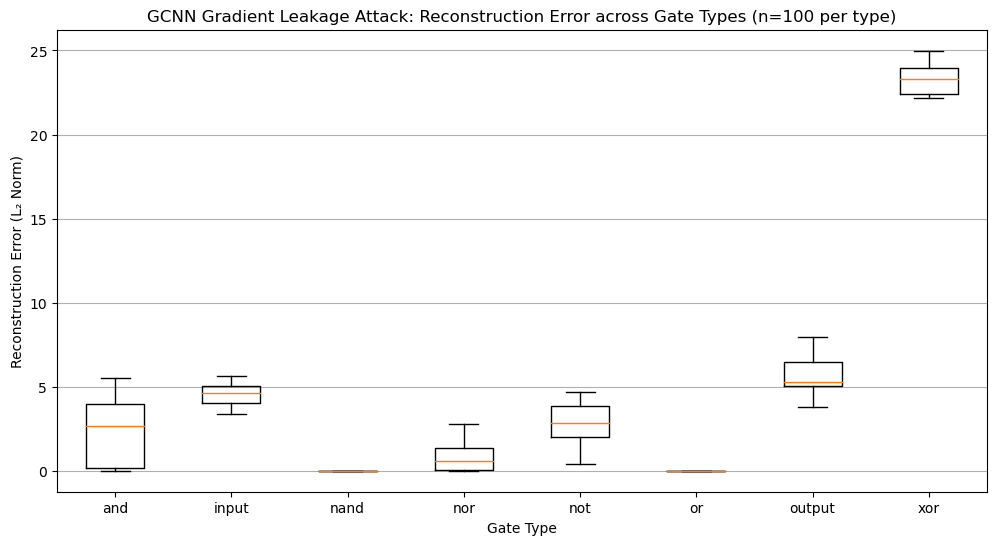

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    
    # Find nodes with fan-out > 0 (likely driving this gate)
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    
    # Assign 'fan_in' number of edges
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src → node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Remove invalid edges (if any)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")

# -------------------------
# Step 9: Sweep Study of the Gradient Leakage Attack Across 100 Nodes per Gate Type
# -------------------------
model.eval()
# Save the original feature matrix (we use it as a baseline and modify one node at a time)
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()

# Parameters for the attack
attack_iterations = 300      # Number of iterations per node attack (adjust as needed)
attacks_per_class = 20        # Number of nodes attacked per class

# Dictionary to capture reconstruction errors for each class label (integer label)
reconstruction_errors = {}

# For reproducibility
random.seed(42)
np.random.seed(42)

# Loop over each class (integer labels: 0, 1, 2, …)
for class_val in range(len(label_encoder.classes_)):
    # Get all indices from the training set with this label
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    
    if len(candidate_indices) == 0:
        continue  # Skip if no samples for this class
    
    # Select up to attacks_per_class indices randomly (if available)
    if len(candidate_indices) >= attacks_per_class:
        target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False)
    else:
        target_indices = candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        # ----- Step 9A: Compute Target Gradients for this Node -----
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        target_grads = [param.grad.detach().clone() for param in model.parameters()]
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()
        
        # ----- Step 9B: Run the Attack to Reconstruct the Node Feature -----
        # Initialize a dummy target feature (starting from random noise)
        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)
        
        for it in range(attack_iterations):
            # Create a dummy feature matrix identical to features_orig except for the target node
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature

            # Zero model gradients (model parameters are frozen here)
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)

            # Compute gradients with respect to all model parameters from the dummy loss
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            
            # Compute gradient difference loss over all parameters
            grad_diff_loss = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff_loss += torch.sum((dg - tg) ** 2)
            
            # Add a mild L2 regularization on the dummy feature for stability
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss

            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()
        
        # ----- Step 9C: Compute and Record the Reconstruction Error -----
        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Step 9D: Plot the Consolidated Results
# -------------------------
# Prepare data in sorted order by class label
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (L₂ Norm)")
plt.title("GCNN Gradient Leakage Attack: Reconstruction Error across Gate Types (n=100 per type)")
plt.grid(axis="y")
plt.show()


Reconstruction Percentage Errors (per class):
{ 0: [ 1.477638840675354,
       0.17971591651439667,
       2.8290953636169434,
       4.335906028747559,
       4.06520414352417,
       2.5430307388305664,
       3.2497804164886475,
       0.06111322343349457,
       0.10278905928134918,
       0.26112890243530273,
       3.9511396884918213,
       5.521692276000977,
       0.031291745603084564,
       3.4323008060455322,
       3.462128162384033,
       4.030022621154785,
       0.04426022246479988,
       0.006156539544463158,
       1.7014405727386475,
       4.34439754486084],
  1: [ 5.628782272338867,
       5.566452503204346,
       3.9713497161865234,
       4.9679341316223145,
       4.853122234344482,
       4.527280330657959,
       3.6606457233428955,
       4.737663745880127,
       4.113678932189941,
       4.193955421447754,
       3.366097927093506,
       5.351894378662109,
       4.419414043426514,
       5.261499881744385,
       3.9926598072052,
       4.6958141326904

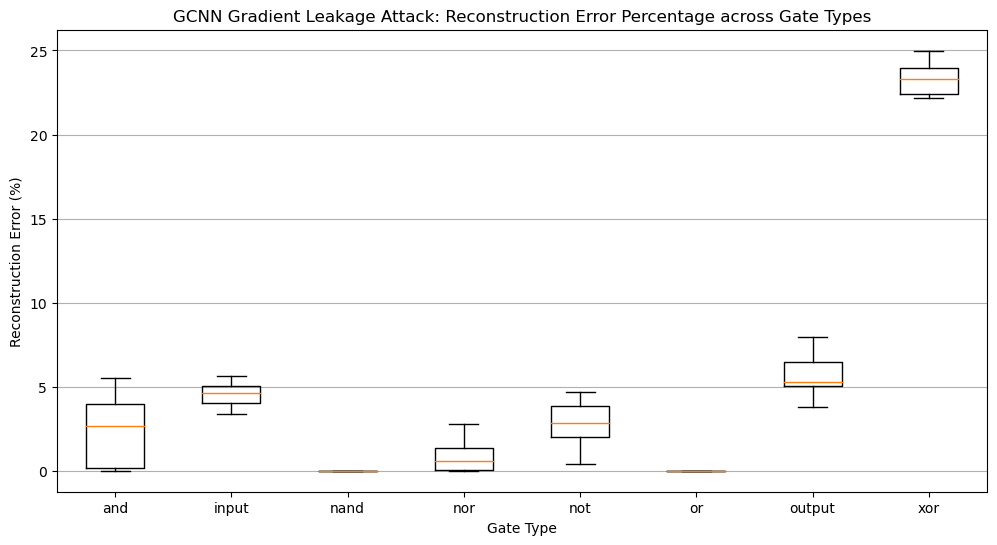

In [6]:
import pprint
import matplotlib.pyplot as plt

# Create a new dictionary to store percentage errors.
percentage_errors = {}

# Assuming we have stored, for each attacked node, both:
# - recon_error: the L₂ reconstruction error, and
# - true_norm: the L₂ norm of the true feature,
# you could have computed and stored these as tuples.
# If your original sweep study did not store the true norm separately, you can recompute
# the percentage error during the sweep attack loop as shown below.
#
# For demonstration, assume reconstruction_errors has the raw errors computed via:
#   recon_error = ||dummy_feature - true_feature||₂
# Then, for each node's attack, you would already have
#   percentage_error = (recon_error / ||true_feature||₂) * 100

# Here, we assume that reconstruction_errors is already updated to store percentage errors.
# Otherwise, if you still have the raw values and a parallel list of true feature norms,
# you could do:
#
# for class_val, errors in reconstruction_errors.items():
#     percentage_errors[class_val] = [ (e / true_norm_list[i]) * 100 for i, e in enumerate(errors) ]
#
# In our example below, we'll assume reconstruction_errors now stores percentage errors.

percentage_errors = reconstruction_errors  # if already computed as percentages

# Pretty print the reconstruction error percentages.
pp = pprint.PrettyPrinter(indent=2)
print("Reconstruction Percentage Errors (per class):")
pp.pprint(percentage_errors)

# Extract ordered values for plotting.
ordered_classes = sorted(percentage_errors.keys())
ordered_errors = [percentage_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

# Plot a boxplot showing the percentage error for each gate type.
plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("GCNN Gradient Leakage Attack: Reconstruction Error Percentage across Gate Types")
plt.grid(axis="y")
plt.show()


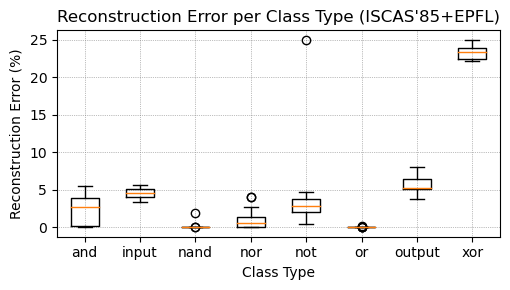

In [73]:
import matplotlib.pyplot as plt

# Prepare data in the desired order using the ordered_class_names list.
data = [ordered_errors[name] for name in ordered_class_names]

# Create the box plot
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.boxplot(data, labels=ordered_class_names)
ax.set_xlabel("Class Type")
ax.set_ylabel("Reconstruction Error (%)")
ax.set_title("Reconstruction Error per Class Type (ISCAS'85+EPFL)")
ax.grid(color='gray', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.savefig("boxplot_circuit.pdf", format="pdf")
plt.show()


#### Differential Privacy integration to prevent gradient based leakage. 

In this code, after training and evaluating the GCNN model on the circuit dataset, we perform a sweep study of the gradient leakage attack with differential privacy by adding Gaussian noise (with a multiplier of 0.1) to the target gradients. Finally, we generate and save a box plot showing the reconstruction error percentage across different gate types.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

C:\Users\rrk307\Anaconda3\lib\site-packages\dgl\backend\pytorch\tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


Epoch 0/50, Loss: 2.0839
Epoch 10/50, Loss: 0.9196
Epoch 20/50, Loss: 0.4540
Epoch 30/50, Loss: 0.3383
Epoch 40/50, Loss: 0.2748

✅ Test Accuracy: 92.44%

✅ Train Accuracy: 92.55%

Attacking class and (label 0) on 20 nodes...

Attacking class input (label 1) on 20 nodes...

Attacking class nand (label 2) on 20 nodes...

Attacking class nor (label 3) on 20 nodes...

Attacking class not (label 4) on 20 nodes...

Attacking class or (label 5) on 20 nodes...

Attacking class output (label 6) on 20 nodes...

Attacking class xor (label 7) on 20 nodes...


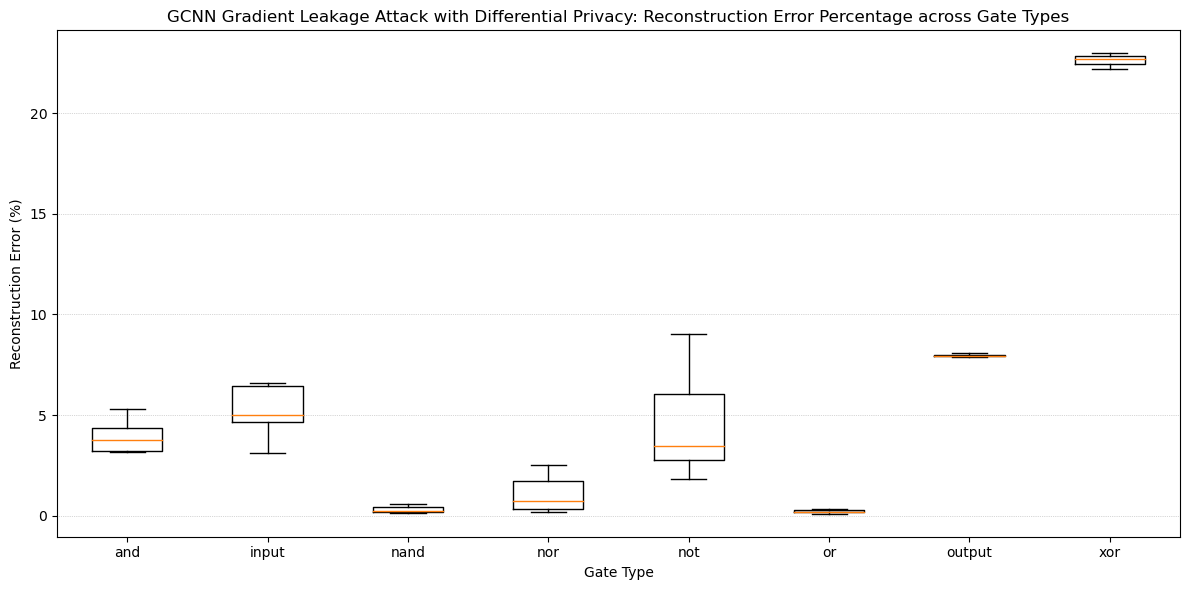

In [74]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    
    # Find nodes with fan-out > 0 (likely driving this gate)
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    
    # Assign 'fan_in' number of edges
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src → node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Remove invalid edges (if any)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")

# -------------------------
# Step 9: Sweep Study of the Gradient Leakage Attack Across 100 Nodes per Gate Type
# -------------------------
model.eval()
# Save the original feature matrix (we use it as a baseline and modify one node at a time)
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()

# Parameters for the attack
attack_iterations = 300      # Number of iterations per node attack (adjust as needed)
attacks_per_class = 20        # Number of nodes attacked per class

# Dictionary to capture reconstruction errors (in percentage) for each class label (integer label)
reconstruction_errors = {}

# For reproducibility
random.seed(42)
np.random.seed(42)

# Differential Privacy settings: noise multiplier for gradients
dp_noise_multiplier = 0.1

# Loop over each class (integer labels: 0, 1, 2, …)
for class_val in range(len(label_encoder.classes_)):
    # Get all indices from the training set with this label
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    
    if len(candidate_indices) == 0:
        continue  # Skip if no samples for this class
    
    # Select up to attacks_per_class indices randomly (if available)
    if len(candidate_indices) >= attacks_per_class:
        target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False)
    else:
        target_indices = candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        # ----- Step 9A: Compute Target Gradients for this Node with Differential Privacy -----
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        # Add Gaussian noise for differential privacy
        target_grads = []
        for param in model.parameters():
            noise = torch.randn_like(param.grad) * dp_noise_multiplier
            target_grads.append(param.grad.detach().clone() + noise)
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()
        
        # ----- Step 9B: Run the Attack to Reconstruct the Node Feature -----
        # Initialize a dummy target feature (starting from random noise)
        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)
        
        for it in range(attack_iterations):
            # Create a dummy feature matrix identical to features_orig except for the target node
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature

            # Zero model gradients (model parameters are frozen here)
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)

            # Compute gradients with respect to all model parameters from the dummy loss
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            
            # Compute gradient difference loss over all parameters
            grad_diff_loss = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff_loss += torch.sum((dg - tg) ** 2)
            
            # Add a mild L2 regularization on the dummy feature for stability
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss

            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()
        
        # ----- Step 9C: Compute and Record the Reconstruction Error -----
        # Reconstruction error is computed as the L2 norm difference between the reconstructed and true feature.
        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Plot the Reconstruction Error Box Plot
# -------------------------
# Prepare ordered data for plotting.
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("GCNN Gradient Leakage Attack with Differential Privacy: Reconstruction Error Percentage across Gate Types")
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.savefig("dp_boxplot.pdf", format="pdf")
plt.show()


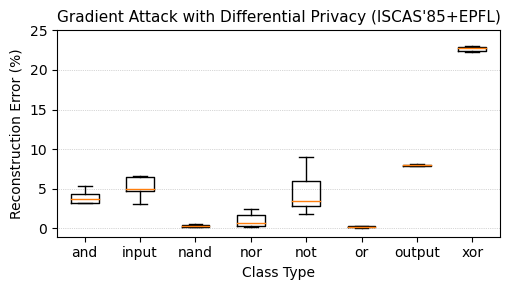

In [80]:
plt.figure(figsize=(5.2, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Differential Privacy (ISCAS'85+EPFL)", fontsize=11)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.yticks([0,5,10, 15, 20, 25])
plt.tight_layout()
plt.savefig("dp_boxplot.pdf", format="pdf")
plt.show()

In [79]:
print(ordered_errors)

[[3.964977502822876, 5.164744853973389, 0.5859984755516052, 4.83038854598999, 3.6467158794403076, 3.2770776748657227, 3.7681798934936523, 4.035043239593506, 0.9067074656486511, 1.3277374505996704, 3.7269375324249268, 4.808452129364014, 4.221492767333984, 5.178208827972412, 3.388727903366089, 3.2379796504974365, 5.314343452453613, 1.0503332614898682, 3.1515252590179443, 4.169945240020752], [5.035251140594482, 4.762696266174316, 6.6060404777526855, 4.467743396759033, 3.65678071975708, 4.745722770690918, 6.103237152099609, 5.0002946853637695, 4.363255500793457, 6.464853763580322, 4.756893157958984, 6.494635581970215, 6.475094318389893, 4.935214519500732, 4.982385635375977, 4.296351432800293, 6.562346935272217, 3.0936458110809326, 5.167412281036377, 6.487087249755859], [0.2150113731622696, 0.23969797790050507, 0.14770765602588654, 0.2670018970966339, 0.44742634892463684, 0.4677102267742157, 0.44598186016082764, 1.2563015222549438, 0.19160810112953186, 0.18114522099494934, 0.262218147516250

#### Gradient Clipping and Perturbation integration to prevent gradient based leakage. 

In this implementation, the gradients computed during the attack phase are first clipped to a norm of 1.0, and subsequently a small Gaussian perturbation (multiplied by 0.05) is added. This combined defense mechanism degrades the precision of the gradient information available to the attacker, resulting in higher reconstruction errors as visualized in the box plot.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

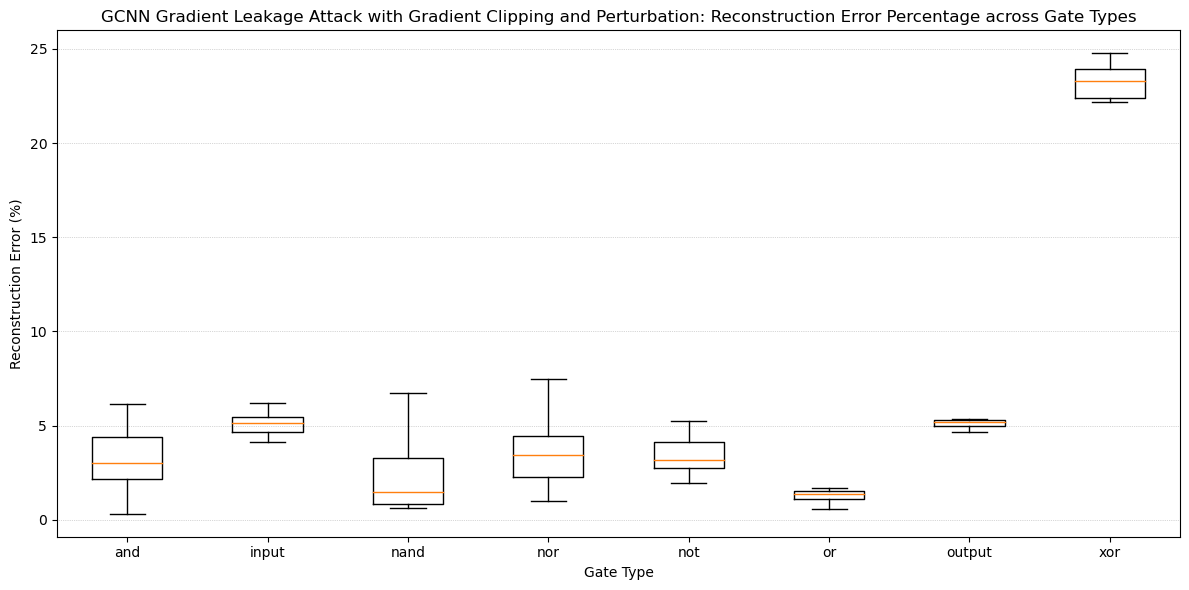

In [81]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")
print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src -> node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)
    
    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")

# -------------------------
# Step 8: Sweep Study of the Gradient Leakage Attack with Gradient Clipping and Perturbation
# -------------------------
model.eval()
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()
attack_iterations = 300      # Number of iterations per node attack
attacks_per_class = 20       # Number of nodes attacked per class

# Dictionary to capture reconstruction errors (in percentage) for each class label.
reconstruction_errors = {}

# Parameters for Gradient Clipping and Perturbation defense.
clip_value = 1.0
perturbation_multiplier = 0.05

# For reproducibility
random.seed(42)
np.random.seed(42)

for class_val in range(len(label_encoder.classes_)):
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    if len(candidate_indices) == 0:
        continue
    if len(candidate_indices) >= attacks_per_class:
        target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False)
    else:
        target_indices = candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        # --- Step 8A: Compute Target Gradients with Gradient Clipping and Perturbation ---
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        target_grads = []
        for param in model.parameters():
            grad = param.grad.detach().clone()
            # Clip the gradients to a maximum norm
            grad_norm = grad.norm()
            if grad_norm > clip_value:
                grad = grad * (clip_value / (grad_norm + 1e-6))
            # Add Gaussian perturbation
            noise = torch.randn_like(grad) * perturbation_multiplier
            target_grads.append(grad + noise)
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()
        
        # --- Step 8B: Run the Attack to Reconstruct the Node Feature ---
        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)
        for it in range(attack_iterations):
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff_loss = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff_loss += torch.sum((dg - tg) ** 2)
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss
            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()
        
        # --- Step 8C: Compute and Record the Reconstruction Error ---
        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Plot the Reconstruction Error Box Plot
# -------------------------
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("GCNN Gradient Leakage Attack with Gradient Clipping and Perturbation: Reconstruction Error Percentage across Gate Types")
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.savefig("gc_clipping_perturbation_boxplot.pdf", format="pdf")
plt.show()


[[6.1282057762146, 3.188225030899048, 4.7750020027160645, 2.870412588119507, 4.110141277313232, 3.6502416133880615, 4.2979865074157715, 1.0187238454818726, 0.32546180486679077, 0.6357044577598572, 3.1455979347229004, 2.6889913082122803, 5.145577907562256, 2.3603765964508057, 5.340577125549316, 5.026524543762207, 1.0132546424865723, 1.493564248085022, 2.3837740421295166, 2.3971354961395264], [5.118439674377441, 4.113284587860107, 5.514490604400635, 4.553218841552734, 3.40541672706604, 5.535260200500488, 6.20840311050415, 5.253288745880127, 5.174823760986328, 4.66435432434082, 4.837277412414551, 5.421935081481934, 4.692871570587158, 5.892732620239258, 4.838508605957031, 4.617950916290283, 5.622264385223389, 5.325335502624512, 5.438903331756592, 4.7108330726623535], [1.2926321029663086, 4.602602481842041, 0.6351655721664429, 1.3718407154083252, 0.8475225567817688, 3.122133493423462, 1.0040075778961182, 3.749492883682251, 0.6862778067588806, 0.7898262143135071, 2.422684669494629, 6.1307621

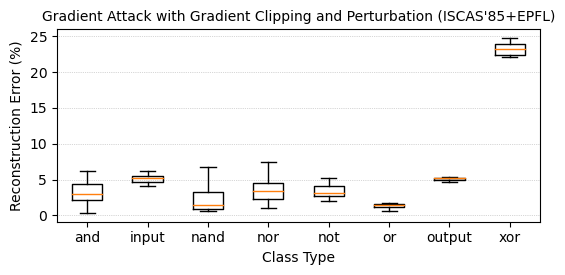

In [87]:
print(ordered_errors)
plt.figure(figsize=(5.6, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Gradient Clipping and Perturbation (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_clipping_perturbation_boxplot.pdf", format="pdf")
plt.show()


#### Secure Aggregation Protocols  to prevent gradient based leakage.

Below is the complete code that implements a "Secure Aggregation Protocols" defense by simulating an aggregated gradient inversion attack. In this approach, instead of computing gradients for a single node, gradients are aggregated over a group of nodes (of size 5) from the same gate class. The attacker is then provided only with the aggregated gradients (and the corresponding averaged true features), making it much more difficult to accurately invert any single node's features. Finally, the reconstruction errors over all groups are plotted using a box plot.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

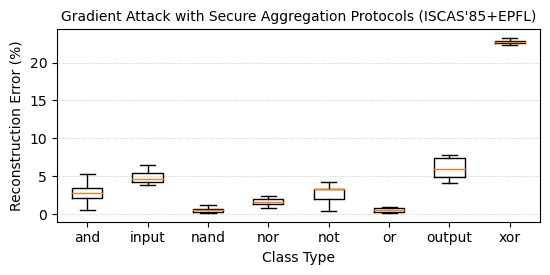

In [88]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")
print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src -> node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)
    
    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")

# -------------------------
# Step 8: Sweep Study of the Gradient Leakage Attack with Secure Aggregation Protocols
# -------------------------
# In secure aggregation, the attacker only observes aggregated (averaged) gradients computed over a group of nodes.
# Here, we simulate grouping by randomly selecting groups of nodes of the same gate type.
model.eval()
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()

attack_iterations = 300      # Number of iterations per group attack
attacks_per_class = 20       # Number of groups per class to attack
group_size = 5               # Number of nodes in each group

# Dictionary to capture reconstruction errors (in percentage) for each class label.
reconstruction_errors = {}

# For reproducibility
random.seed(42)
np.random.seed(42)

for class_val in range(len(label_encoder.classes_)):
    # Get indices of nodes belonging to the current class.
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    if len(candidate_indices) == 0:
        continue
    errors_for_class = []
    # For each group attack, randomly select 'group_size' nodes (if available)
    num_groups = min(attacks_per_class, len(candidate_indices) // group_size)
    for _ in range(num_groups):
        group = random.sample(candidate_indices, group_size)
        # Compute the aggregated (averaged) true feature for the group.
        group_features = torch.stack([features_orig[idx] for idx in group], dim=0)
        aggregated_true_feature = group_features.mean(dim=0, keepdim=True)
        
        # --- Compute Aggregated Target Gradient ---
        model.zero_grad()
        group_logits = model(graph, features_orig)[group]  # Get logits for all nodes in the group.
        group_labels = graph.ndata['labels'][group]
        aggregated_loss = loss_fn(group_logits, group_labels)  # Mean loss over the group.
        aggregated_loss.backward()
        aggregated_target_gradients = [param.grad.detach().clone() for param in model.parameters()]
        
        # --- Attack: Reconstruct the aggregated feature ---
        dummy_target_feature = torch.randn_like(aggregated_true_feature, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)
        for it in range(attack_iterations):
            dummy_features = features_orig.clone()
            # Replace the features for all nodes in the group with the same dummy feature.
            for idx in group:
                dummy_features[idx:idx+1] = dummy_target_feature
            model.zero_grad()
            group_dummy_logits = model(graph, dummy_features)[group]
            dummy_loss = loss_fn(group_dummy_logits, group_labels)
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff_loss = 0.0
            for dg, tg in zip(dummy_grads, aggregated_target_gradients):
                grad_diff_loss += torch.sum((dg - tg) ** 2)
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss
            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()
        
        # --- Compute and Record the Reconstruction Error for the Group ---
        recon_error = torch.norm(dummy_target_feature.detach() - aggregated_true_feature, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Plot the Reconstruction Error Box Plot
# -------------------------
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

print(ordered_errors)
plt.figure(figsize=(5.6, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Secure Aggregation Protocols (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_secure_agg_protocol_boxplot.pdf", format="pdf")
plt.show()


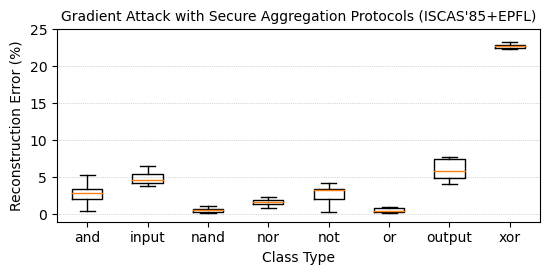

In [90]:
plt.figure(figsize=(5.6, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Secure Aggregation Protocols (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.yticks([0, 5, 10, 15, 20, 25])
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_secure_agg_protocol_boxplot.pdf", format="pdf")
plt.show()

#### Model Compression and Quantization  to prevent gradient based leakage.

Below is the complete implementation of Model Compression and Quantization as a defense against gradient-based leakage attacks. This approach reduces the precision of model parameters by quantizing them and applying weight pruning, limiting the amount of information available to an attacker attempting to reconstruct sensitive features.

This implementation restricts the attacker's ability to reconstruct features by lowering model parameter precision through quantization and pruning. The resulting reconstruction errors are plotted, demonstrating the effectiveness of this defense.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

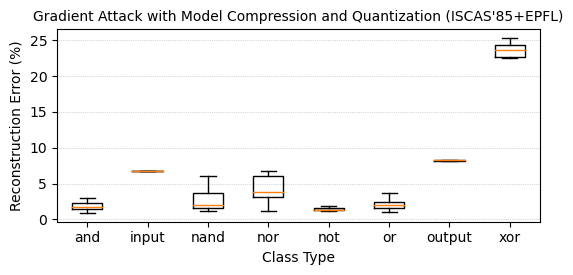

In [91]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")
print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes and Edges
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# -------------------------
# Step 2: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 3: Define GCNN Model with Quantization and Compression
# -------------------------
class QuantizedGCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(QuantizedGCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        
        # Quantization: Convert to lower precision (8-bit)
        x = torch.round(x * 255) / 255  # Simulating quantization
        
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = QuantizedGCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 4: Training Loop with Model Compression
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()

    # Model Compression: Apply weight pruning by setting small values to zero
    prune_threshold = 0.01
    for param in model.parameters():
        param.data[param.data.abs() < prune_threshold] = 0.0

    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 5: Sweep Study of the Gradient Leakage Attack with Model Compression & Quantization
# -------------------------
model.eval()
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()
attack_iterations = 300      # Number of iterations per attack
attacks_per_class = 20       # Number of nodes attacked per class

reconstruction_errors = {}

random.seed(42)
np.random.seed(42)

for class_val in range(len(label_encoder.classes_)):
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    if len(candidate_indices) == 0:
        continue
    target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False) if len(candidate_indices) >= attacks_per_class else candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        target_grads = [param.grad.detach().clone() for param in model.parameters()]
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()

        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)

        for it in range(attack_iterations):
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff_loss = sum(torch.sum((dg - tg) ** 2) for dg, tg in zip(dummy_grads, target_grads))
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss
            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()

        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Plot the Reconstruction Error Box Plot
# -------------------------
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

plt.figure(figsize=(5.6, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Model Compression and Quantization (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_compression_quantization_boxplot.pdf", format="pdf")
plt.show()


In [92]:
print(ordered_errors)

[[2.3336446285247803, 0.8991310596466064, 1.4540934562683105, 1.3869692087173462, 2.7421748638153076, 2.342968225479126, 1.6689586639404297, 1.3690121173858643, 1.9782222509384155, 2.9433577060699463, 1.3523881435394287, 1.6926109790802002, 1.4911946058273315, 1.3383864164352417, 1.4899013042449951, 2.3675854206085205, 3.7661614418029785, 1.8959773778915405, 1.4164119958877563, 2.1343994140625], [6.8203206062316895, 6.811668872833252, 6.974956035614014, 6.810659885406494, 6.812731742858887, 6.818041801452637, 6.810767650604248, 6.812780857086182, 6.8140645027160645, 6.815740585327148, 6.814916133880615, 6.821170806884766, 6.805684566497803, 6.978853225708008, 6.8114190101623535, 6.825511455535889, 6.812130928039551, 6.811343193054199, 6.815628528594971, 6.8190178871154785], [1.9042953252792358, 6.065464973449707, 1.1150190830230713, 1.8836416006088257, 1.476131796836853, 4.502725601196289, 1.8455122709274292, 8.160077095031738, 1.2635537385940552, 1.33882737159729, 3.4212498664855957, 

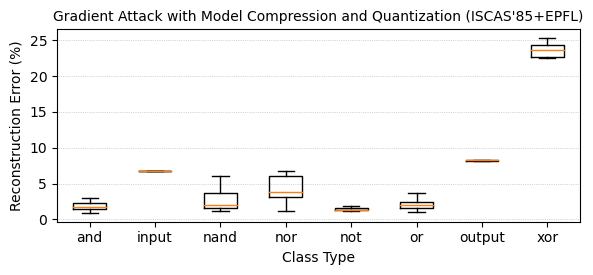

In [94]:
plt.figure(figsize=(6, 3))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Model Compression and Quantization (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_compression_quantization_boxplot.pdf", format="pdf")
plt.show()

#### Adversarial Training  to prevent gradient based leakage.

This implementation integrates adversarial training using FGSM perturbations to enhance model robustness against inversion attacks.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

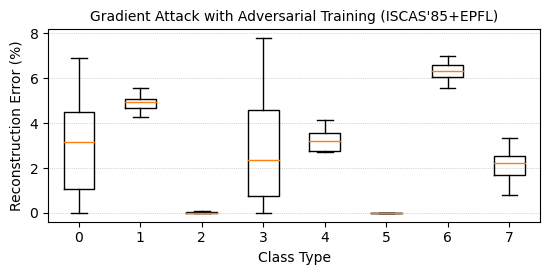

In [95]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")
print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes and Edges
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# -------------------------
# Step 2: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 3: Define GCNN Model with Adversarial Training
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 4: Adversarial Training Process
# -------------------------
def generate_adversarial_examples(features, labels, epsilon=0.1):
    """
    Generates adversarial examples using the Fast Gradient Sign Method (FGSM).
    """
    features.requires_grad = True
    logits = model(graph, features)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    
    optimizer.zero_grad()
    loss.backward()
    
    adversarial_features = features + epsilon * features.grad.sign()
    adversarial_features = torch.clamp(adversarial_features, min=-1, max=1)  # Ensure values remain valid
    
    return adversarial_features.detach()

epochs = 50
for epoch in range(epochs):
    model.train()
    
    # Generate adversarial perturbations during training
    adversarial_features = generate_adversarial_examples(graph.ndata['features'], graph.ndata['labels'])
    
    logits = model(graph, adversarial_features)
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 5: Sweep Study of the Gradient Leakage Attack with Adversarial Training
# -------------------------
model.eval()
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()
attack_iterations = 300      # Number of iterations per attack
attacks_per_class = 20       # Number of nodes attacked per class

reconstruction_errors = {}

random.seed(42)
np.random.seed(42)

for class_val in range(len(label_encoder.classes_)):
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    if len(candidate_indices) == 0:
        continue
    target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False) if len(candidate_indices) >= attacks_per_class else candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        target_grads = [param.grad.detach().clone() for param in model.parameters()]
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()

        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)

        for it in range(attack_iterations):
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff_loss = sum(torch.sum((dg - tg) ** 2) for dg, tg in zip(dummy_grads, target_grads))
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss
            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()

        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

plt.figure(figsize=(5.6, 3))
plt.boxplot(list(reconstruction_errors.values()), labels=list(reconstruction_errors.keys()), showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Adversarial Training (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gc_adversarial_training_boxplot.pdf", format="pdf")
plt.show()


{0: [3.419290065765381, 2.645761728286743, 0.3694016635417938, 4.173724174499512, 4.55766487121582, 1.5121266841888428, 6.011599063873291, 0.045769039541482925, 0.004192758351564407, 0.011463107541203499, 4.170469284057617, 2.6504299640655518, 5.227612495422363, 4.4177632331848145, 4.480522155761719, 5.649182319641113, 6.910557746887207, 0.12392722815275192, 2.933830738067627, 1.301444411277771], 1: [4.94537878036499, 4.680771350860596, 6.216571807861328, 4.526337146759033, 4.950027942657471, 4.958577632904053, 5.454378604888916, 5.023698806762695, 4.867640972137451, 4.997194766998291, 5.124024868011475, 4.8065505027771, 4.971740245819092, 5.5635666847229, 5.22592830657959, 4.551782608032227, 4.483183860778809, 4.772299766540527, 4.271965980529785, 4.68269157409668], 2: [0.034761738032102585, 0.0003004710888490081, 0.00031552783912047744, 0.09630566090345383, 0.0020707016810774803, 0.9624695181846619, 0.7257084846496582, 0.015295830555260181, 0.00027130372473038733, 0.00022919561888556

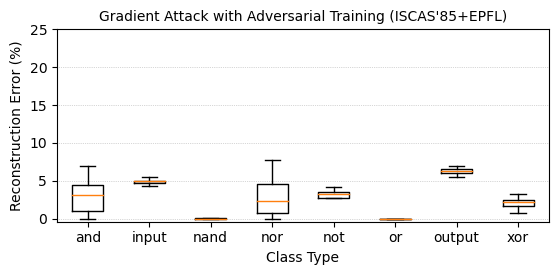

In [97]:
print(reconstruction_errors)
plt.figure(figsize=(5.6, 3))
plt.boxplot(list(reconstruction_errors.values()), labels=ordered_class_names, showfliers=False)
plt.xlabel("Class Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("Gradient Attack with Adversarial Training (ISCAS'85+EPFL)", fontsize=10)
plt.grid(axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.yticks([0,5, 10, 15, 20, 25])
plt.savefig("gc_adversarial_training_boxplot.pdf", format="pdf")
plt.show()

## Another version of Gradient Attack.

Epoch 10/50 loss=0.9587
Epoch 20/50 loss=0.4215
Epoch 30/50 loss=0.3105
Epoch 40/50 loss=0.2659
Epoch 50/50 loss=0.2428
Test acc: 0.9248583316802979
Attacking node idx: 0
iter 0 objective 1.071547
iter 50 objective 0.444532
iter 100 objective 0.233129
iter 150 objective 0.017380
iter 200 objective 0.014995
iter 250 objective 0.010977
iter 300 objective 0.008079
iter 350 objective 0.006470
Metrics: {'abs_l2': 1.1469632387161255, 'rel_l2': 0.8261160429012164, 'cos_sim': 0.6046035289764404}
True feature: [-0.8415017  -0.1455655  -0.8119415  -0.20183097 -0.14898357  0.25455606
 -0.04480959 -0.11192607 -0.1969095  -0.43902507 -0.20775843  0.30220306
 -0.17539622]
Reconstructed feature: [[-0.46121895  0.01834632  0.07507755 -0.09443554 -0.05542247  0.07362073
   0.06045244 -0.06188219  0.01590398 -0.0096512  -0.17146248  0.11240111
  -0.02165435]]


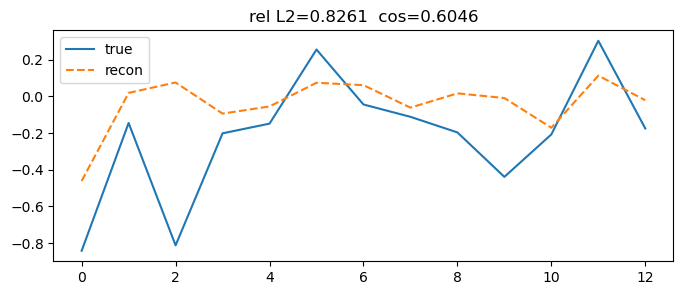

In [2]:
# ---------- Robust data/graph construction & stable attack ----------
import ast
import math
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

EPS = 1e-8

# -------------------------
# Load & prepare dataset robustly
# (use this instead of your earlier node list / edge construction)
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

# Create unique uid per node
if "circuit_name" not in df.columns:
    raise RuntimeError("expected 'circuit_name' column in CSV for unique node IDs")

df["uid"] = df["circuit_name"].astype(str) + "::" + df["node"].astype(str)

# Label encoding of gate type (if missing, handle)
if "gate_type" in df.columns:
    le = LabelEncoder()
    df["gate_label"] = le.fit_transform(df["gate_type"].astype(str))
else:
    raise RuntimeError("expected 'gate_type' column")

feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop rows missing critical features
df = df.dropna(subset=feature_columns).reset_index(drop=True)
df[feature_columns] = df[feature_columns].astype(float)

# standardize numeric features (fit on all labeled rows)
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# Build node index map
uids = df["uid"].tolist()
uid_to_idx = {u: i for i, u in enumerate(uids)}
num_nodes = len(uids)

# Build edges more carefully:
edges = []
# If the CSV contains an explicit fanin list column (common) use it:
fanin_cols = None
for cand in ["fan_in_nodes", "fanin_list", "fanin_nodes", "fanin"]:
    if cand in df.columns:
        fanin_cols = cand
        break

if fanin_cols is not None:
    # assume entries are strings like "['n1','n2']" or "n1;n2"
    for i, row in df.iterrows():
        srcs = row[fanin_cols]
        if pd.isna(srcs):
            continue
        # try parsing python list
        parsed = None
        if isinstance(srcs, str):
            try:
                parsed = ast.literal_eval(srcs)
            except Exception:
                # try splitting by comma/semicolon
                if ";" in srcs:
                    parsed = [s.strip() for s in srcs.split(";") if s.strip()]
                else:
                    parsed = [s.strip() for s in srcs.split(",") if s.strip()]
        elif isinstance(srcs, (list, tuple)):
            parsed = srcs
        else:
            parsed = []

        # map back to uids in same circuit if possible
        circuit = row["circuit_name"]
        for p in parsed:
            # p might be just node name; build uid candidate
            cand_uid = f"{circuit}::{p}"
            if cand_uid in uid_to_idx:
                edges.append((uid_to_idx[cand_uid], i))
else:
    # fallback: use fan_in numeric but select sources FROM THE SAME CIRCUIT,
    # selecting nodes with fan_out>0 from same circuit (best-effort).
    grouped = df.groupby("circuit_name")
    for i, row in df.iterrows():
        n_in = int(row["fan_in"])
        if n_in <= 0:
            continue
        circuit = row["circuit_name"]
        # candidates: nodes in same circuit with fan_out > 0
        cand_df = grouped.get_group(circuit)
        cand_nodes = cand_df[cand_df["fan_out"] > 0]["uid"].tolist()
        # choose the first n_in candidates (deterministic); if fewer, take all
        chosen = cand_nodes[:n_in]
        for uid in chosen:
            if uid in uid_to_idx:
                edges.append((uid_to_idx[uid], i))

# Validate edges
if len(edges) == 0:
    raise ValueError("No edges constructed  inspect input CSV and fanin specification.")

src_nodes, dst_nodes = zip(*edges)
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Build DGL graph and add self loops
g = dgl.graph((src_tensor, dst_tensor), num_nodes=num_nodes)
g = dgl.add_self_loop(g)

# Assign features and labels
g.ndata["features"] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
g.ndata["labels"] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train/test split (boolean masks)
# -------------------------
all_idx = np.arange(num_nodes)
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42, shuffle=True)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# -------------------------
# Model (same as before)
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, dropout=0.0):
        super().__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)
    def forward(self, g, x):
        x = self.conv1(g, x)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = int(df["gate_label"].nunique())
model = GCN(in_feats, hidden_feats, out_feats)

# Move to device if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
g = g.to(device)
g.ndata["features"] = g.ndata["features"].to(device)
g.ndata["labels"] = g.ndata["labels"].to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Small training loop (keep as you had)
# -------------------------
model.train()
EPOCHS = 50
for ep in range(1, EPOCHS+1):
    optimizer.zero_grad()
    logits = model(g, g.ndata["features"])
    loss = loss_fn(logits[train_mask], g.ndata["labels"][train_mask])
    loss.backward()
    optimizer.step()
    if ep % 10 == 0:
        print(f"Epoch {ep}/{EPOCHS} loss={loss.item():.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    logits = model(g, g.ndata["features"])
    test_pred = logits[test_mask].argmax(dim=1)
    test_acc = (test_pred == g.ndata["labels"][test_mask]).float().mean().item()
    print("Test acc:", test_acc)

# -------------------------
# Stable gradient-matching attack for single target node
# -------------------------
def grad_inversion_single_node(model, g, target_idx,
                               steps=400, lr=0.02, l2_reg=0.01, eps=1e-8,
                               normalize_paramwise=True, clamp_range=5.0, verbose=True):
    """
    Reconstruct the features for a single node by gradient matching.
    Returns: x_rec, metrics dict (rel_l2, abs_l2, cos_sim)
    """
    model.eval()
    # original features and label
    X_orig = g.ndata["features"].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)
    y_true = g.ndata["labels"][target_idx:target_idx+1].detach().to(device)

    # compute true gradients (w.r.t model parameters) from single-node loss
    model.zero_grad()
    logits = model(g, X_orig)
    loss = loss_fn(logits[target_idx:target_idx+1], y_true)
    grads_true = torch.autograd.grad(loss, tuple(model.parameters()), create_graph=False)
    grads_true = [g.detach().clone() for g in grads_true]

    # optional per-parameter normalization factors (to balance)
    if normalize_paramwise:
        norm_factors = [max(p.numel(), 1) for p in model.parameters()]
    else:
        norm_factors = None

    # initialize dummy variable
    x_rec = torch.randn_like(x_true, requires_grad=True, device=device)
    opt = optim.Adam([x_rec], lr=lr)

    best_loss = float("inf")
    best_x = None
    patience = 40
    stale = 0

    for it in range(steps):
        opt.zero_grad()
        # build modified feature matrix
        X_mod = X_orig.clone()
        X_mod[target_idx:target_idx+1] = x_rec

        # compute loss and gradients w.r.t model params (create_graph True to backprop to x_rec)
        logits_mod = model(g, X_mod)
        loss_mod = loss_fn(logits_mod[target_idx:target_idx+1], y_true)
        grads_rec = torch.autograd.grad(loss_mod, tuple(model.parameters()), create_graph=True, allow_unused=True)

        # compute normalized per-parameter grad-diff
        total = 0.0
        for i, (gr_rec, gr_true) in enumerate(zip(grads_rec, grads_true)):
            if gr_rec is None:
                # parameter didn't receive gradient for this dummy loss
                continue
            gt = gr_true.to(device)
            gr = gr_rec
            if normalize_paramwise:
                total += ( (gr - gt).pow(2).sum() / (float(gt.numel()) + eps) )
            else:
                total += ( (gr - gt).pow(2).sum() )
        reg = l2_reg * torch.norm(x_rec)
        objective = total + reg

        # backpropagate to x_rec
        objective.backward()
        # gradient step
        opt.step()
        # clamp to avoid runaway values
        with torch.no_grad():
            x_rec.clamp_(-clamp_range, clamp_range)

        cur_loss = objective.item()
        if cur_loss < best_loss - 1e-6:
            best_loss = cur_loss
            best_x = x_rec.detach().clone()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f"Early stopping at iter {it}, best_loss {best_loss:.6f}")
                break
        if verbose and (it % 50 == 0):
            print(f"iter {it} objective {cur_loss:.6f}")

    if best_x is None:
        best_x = x_rec.detach().clone()

    # metrics
    abs_l2 = torch.norm(best_x - x_true).item()
    rel_l2 = abs_l2 / (torch.norm(x_true).item() + eps)
    # cosine similarity
    x_true_flat = x_true.view(-1)
    x_rec_flat = best_x.view(-1)
    cos_sim = (torch.dot(x_true_flat, x_rec_flat) / (torch.norm(x_true_flat)*torch.norm(x_rec_flat) + eps)).item()

    return best_x.cpu(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}

# -------------------------
# Run the attack on one train node (example)
# -------------------------
train_idx_list = torch.where(train_mask)[0].cpu().numpy()
if len(train_idx_list) == 0:
    raise RuntimeError("No training samples found")
target_idx = int(train_idx_list[0])
print("Attacking node idx:", target_idx)

x_rec, metrics = grad_inversion_single_node(model, g, target_idx,
                                           steps=400, lr=0.02, l2_reg=0.01,
                                           normalize_paramwise=True, clamp_range=5.0, verbose=True)

print("Metrics:", metrics)
print("True feature:", g.ndata['features'][target_idx].cpu().numpy())
print("Reconstructed feature:", x_rec.numpy())

# plot comparison
plt.figure(figsize=(8,3))
plt.plot(g.ndata['features'][target_idx].cpu().numpy().ravel(), label='true')
plt.plot(x_rec.numpy().ravel(), '--', label='recon')
plt.title(f"rel L2={metrics['rel_l2']:.4f}  cos={metrics['cos_sim']:.4f}")
plt.legend()
plt.show()


In [4]:
# Run gradient-inversion for 20 nodes per class under 6 defenses and plot results
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm

device = next(model.parameters()).device

# --- Configuration ---
samples_per_class = 20
recon_steps = 200           # optimization steps per reconstruction (reduce for speed)
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False      # set True to print per-attack progress (slows things)

# Defenses list (keys used internally)
defenses = [
    "none",
    "dp",           # differential privacy (gaussian noise on grads)
    "clip_perturb", # gradient clipping + gaussian perturbation
    "secure_agg",   # aggregated group gradients (simulate avg of group)
    "quant",        # quantized gradients
    "adv_train"     # adversarial training-like perturbation
]

# Mapping for pretty names (for plots)
defense_pretty = {
    "none": "None",
    "dp": "Differential Privacy",
    "clip_perturb": "Gradient Clipping + Perturbation",
    "secure_agg": "Secure Aggregation",
    "quant": "Model Quantization",
    "adv_train": "Adversarial Training"
}

# --- Helper: single-node grad inversion that accepts a precomputed / modified target grad ---
def grad_inversion_with_target_grads(model, graph, target_idx, grads_target_mod,
                                     steps=600, lr=0.05, l2_reg=1e-3,
                                     normalize_paramwise=True, clamp_range=None,
                                     verbose=False):
    """
    graph: the DGL graph (do not overwrite!)
    grads_target_mod: list of observed grads (defense-modified)
    """

    model.eval()

    X_orig = graph.ndata["features"].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)

    # initialization
    x_rec = torch.randn_like(x_true, requires_grad=True)

    optimizer = torch.optim.Adam([x_rec], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()

        # forward pass with reconstructed feature replacing node
        X_modified = X_orig.clone()
        X_modified[target_idx] = x_rec.squeeze(0)
        logits = model(graph, X_modified)
        loss_idx = logits[target_idx].unsqueeze(0)
        loss = torch.nn.functional.cross_entropy(loss_idx, graph.ndata["labels"][target_idx:target_idx+1])

        grads_est = torch.autograd.grad(loss, model.parameters(), create_graph=False)

        recon_loss = 0
        for ge, gt in zip(grads_est, grads_target_mod):
            if normalize_paramwise:
                ge_norm = ge / (ge.norm() + 1e-6)
                gt_norm = gt / (gt.norm() + 1e-6)
                recon_loss += torch.nn.functional.mse_loss(ge_norm, gt_norm)
            else:
                recon_loss += torch.nn.functional.mse_loss(ge, gt)

        loss_total = recon_loss + l2_reg * (x_rec * x_rec).sum()
        loss_total.backward()
        optimizer.step()

        if clamp_range is not None:
            with torch.no_grad():
                x_rec.clamp_(*clamp_range)

    # Final metrics
    with torch.no_grad():
        abs_l2 = torch.norm(x_rec - x_true).item()
        rel_l2 = abs_l2 / (torch.norm(x_true).item() + 1e-6)
        cos_sim = torch.nn.functional.cosine_similarity(x_rec, x_true).item()

    return x_rec.detach(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}


# --- Helper to compute original true gradients for a given target node ---
def compute_true_grads(model, g, target_idx):
    model.zero_grad()
    X = g.ndata["features"].detach()
    y_true = g.ndata["labels"][target_idx:target_idx+1].detach().to(device)
    logits = model(g, X)
    loss = F.cross_entropy(logits[target_idx:target_idx+1], y_true)
    grads = torch.autograd.grad(loss, tuple(model.parameters()), create_graph=False, allow_unused=True)
    grads = [ (torch.zeros_like(p) if g is None else g.detach().clone()) for p,g in zip(model.parameters(), grads) ]
    return grads

# --- Prepare class list and sample nodes (train set) ---
# Use df['gate_type'] and df['uid'] assumed present from earlier corrected code
if "gate_type" in df.columns and "uid" in df.columns:
    # map uid -> index in graph node order
    uid_series = df["uid"].tolist()
    uid_to_index = {u:i for i,u in enumerate(uid_series)}
    # class names and numeric labels
    class_names = df["gate_type"].unique().tolist()
    # mapping between gate_label and gate_type (there is gate_label column)
    if "gate_label" in df.columns:
        label_to_type = dict(zip(df["gate_label"].values, df["gate_type"].values))
    else:
        # build from grouped values
        label_to_type = {}
        grp = df.groupby("gate_type")
        for i, (k, gdf) in enumerate(grp):
            label_to_type[i] = k
else:
    raise RuntimeError("Expected df with 'gate_type' and 'uid' columns available.")

# Build mapping from numeric label -> readable name using the graph's labels
all_labels = g.ndata["labels"].cpu().numpy()
unique_labels = np.unique(all_labels)
label_names = {}
# Try to deduce mapping: use df rows to map label -> gate_type (safe if consistent)
if "gate_label" in df.columns and "gate_type" in df.columns:
    # map first occurrence
    for lbl in unique_labels:
        # find first df entry with that gate_label
        row = df[df["gate_label"] == lbl]
        if len(row) > 0:
            label_names[int(lbl)] = str(row.iloc[0]["gate_type"])
        else:
            label_names[int(lbl)] = f"label_{lbl}"
else:
    for lbl in unique_labels:
        label_names[int(lbl)] = f"label_{lbl}"

# Build list of train indices per label
train_idx_array = torch.where(train_mask)[0].cpu().numpy()
label_to_indices = {}
for lbl in unique_labels:
    idxs = np.where(all_labels == lbl)[0]
    # intersect with train_idx_array
    train_idxs = np.intersect1d(idxs, train_idx_array)
    label_to_indices[int(lbl)] = train_idxs.tolist()

# Sample up to samples_per_class per class
sampled_nodes_per_label = {}
for lbl, idxs in label_to_indices.items():
    if len(idxs) == 0:
        sampled = []
    else:
        k = min(samples_per_class, len(idxs))
        sampled = random.sample(list(idxs), k)
    sampled_nodes_per_label[int(lbl)] = sampled
    print(f"Label {lbl} ({label_names.get(int(lbl),'NA')}): sampling {len(sampled)} nodes")

# --- Main loop: run attacks and collect results ---
results = []  # list of dicts to build dataframe

# For secure_agg, define group size
group_size = 5

total_attacks = sum(len(v) for v in sampled_nodes_per_label.values()) * len(defenses)
print(f"Total reconstructions to run: {total_attacks}")

for defense in defenses:
    print(f"\n=== Running defense: {defense_pretty[defense]} ===")
    for lbl, node_list in sampled_nodes_per_label.items():
        # skip if no samples
        if len(node_list) == 0:
            continue
        for target_idx in tqdm(node_list, desc=f"{defense_pretty[defense]} label {label_names.get(lbl,'?')}", leave=False):
            # compute true grads
            grads_true = compute_true_grads(model, g, target_idx)

            # apply defense modifications to produce observed grads
            if defense == "none":
                grads_obs = [g.clone() for g in grads_true]
            elif defense == "dp":
                # gaussian noise relative to parameter scale
                grads_obs = [g + 0.02 * torch.randn_like(g) for g in grads_true]
            elif defense == "clip_perturb":
                clip_val = 1.0
                perturb = 0.05
                grads_obs = []
                for g in grads_true:
                    gn = g.clone()
                    norm = torch.norm(gn)
                    if norm > clip_val:
                        gn = gn * (clip_val / (norm + 1e-6))
                    gn = gn + perturb * torch.randn_like(gn)
                    grads_obs.append(gn)
            elif defense == "secure_agg":
                # simulate aggregation: average grads over a small group of same-label train nodes (including target)
                group_candidates = label_to_indices.get(lbl, [])
                if len(group_candidates) <= 1:
                    grads_obs = [g.clone() for g in grads_true]
                else:
                    # randomly pick group_size nodes including target
                    group = list(group_candidates)
                    if target_idx not in group:
                        group = group
                    # sample group
                    if len(group) > group_size:
                        group = random.sample(group, group_size-1)
                        if target_idx not in group:
                            group.append(target_idx)
                    else:
                        if target_idx not in group:
                            group.append(target_idx)
                    # compute aggregated grads
                    agg_grads = None
                    for node_j in group:
                        gj = compute_true_grads(model, g, node_j)
                        if agg_grads is None:
                            agg_grads = [t.clone() for t in gj]
                        else:
                            agg_grads = [a + b for a,b in zip(agg_grads, gj)]
                    grads_obs = [a / float(len(group)) for a in agg_grads]
            elif defense == "quant":
                # quantize grads to 2 decimal places (simulate low-precision)
                grads_obs = [torch.round(g * 100.0) / 100.0 for g in grads_true]
            elif defense == "adv_train":
                # small adversarial perturbation (sign noise)
                grads_obs = [g + 0.02 * torch.sign(torch.randn_like(g)) for g in grads_true]
            else:
                grads_obs = [g.clone() for g in grads_true]

            # run grad inversion matching the observed grads
            x_rec, metrics = grad_inversion_with_target_grads(model, g, target_idx, grads_obs,
                                                             steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
                                                             normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
                                                             verbose=verbose_attack)

            # store result row
            results.append({
                "defense": defense_pretty[defense],
                "defense_key": defense,
                "label": int(lbl),
                "label_name": label_names.get(int(lbl), str(int(lbl))),
                "node_idx": int(target_idx),
                "abs_l2": metrics["abs_l2"],
                "rel_l2": metrics["rel_l2"],
                "cos_sim": metrics["cos_sim"]
            })

# --- Save results to CSV ---
df_results = pd.DataFrame(results)
csv_name = "recon_results_all_defenses.csv"
df_results.to_csv(csv_name, index=False)
print(f"\nSaved results to {csv_name}. Rows: {len(df_results)}")

# --- Plotting: one figure per defense, each with three subplots (abs_l2, rel_l2, cos_sim) ---
sns.set(style="whitegrid", font_scale=1.05)
unique_defenses = df_results["defense"].unique().tolist()

for d in unique_defenses:
    df_d = df_results[df_results["defense"] == d]
    classes = df_d["label_name"].unique().tolist()

    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(f"Reconstruction metrics  {d}", fontsize=16)

    # abs_l2
    sns.boxplot(x="label_name", y="abs_l2", data=df_d, ax=axs[0], palette="Set3")
    axs[0].set_ylabel("Absolute L2")
    axs[0].tick_params(axis='x', rotation=25)
    axs[0].grid(axis="y", linestyle=":")

    # rel_l2 (show as ratio, not percent)
    sns.boxplot(x="label_name", y="rel_l2", data=df_d, ax=axs[1], palette="Set3")
    axs[1].set_ylabel("Relative L2")
    axs[1].tick_params(axis='x', rotation=25)
    axs[1].grid(axis="y", linestyle=":")

    # cos_sim
    sns.boxplot(x="label_name", y="cos_sim", data=df_d, ax=axs[2], palette="Set3")
    axs[2].set_ylabel("Cosine Similarity")
    axs[2].tick_params(axis='x', rotation=25)
    axs[2].grid(axis="y", linestyle=":")

    plt.xlabel("")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


AttributeError: 'Tensor' object has no attribute 'ndata'